In [82]:
import random
random.seed(42)
np.random.seed(42)

import numpy as np
from scipy.stats import norm

import pymdp
from pymdp import utils
from pymdp.agent import Agent

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

from river.preprocessing import StandardScaler
from river.drift import ADWIN
from river.ensemble import SRPRegressor
from river.tree import HoeffdingTreeRegressor

import warnings
warnings.filterwarnings('ignore')

# Utilities

In [83]:
def get_most_probable_indices(qs):
    return [np.argmax(q) for q in qs]

In [84]:
def get_max_prob_index(prob_array):
    return int(np.argmax(prob_array))

In [85]:
def step_print(produzione1, produzione2, segnale1, segnale2, vendite1, vendite2, magazzino1, magazzino2, ware_levels):
    print(f"Produzione 1: {produzione1}, Produzione 2: {produzione2}")
    print(f"Segnale analisi 1: {segnale1}, Segnale analisi 2: {segnale2}")
    print(f"Vendite 1: {vendite1}, Vendite 2: {vendite2}")
    print(f"Magazzino 1: {magazzino1, ware_levels[0]}, Magazzino 2: {magazzino2, ware_levels[1]}")
    print("--------------------------------------------------")

In [86]:
def return_level(warehouses,pf_lev, ic_lev, oc_lev):
    levels = [""] * len(warehouses)
    for i,j in enumerate(warehouses):
        if j < pf_lev:
            levels[i] = "perfect"
        elif pf_lev-1 < j < ic_lev:
            levels[i] = "in control"
        elif j > oc_lev:
            levels[i] = "out of control"
        else:
            levels[i] = "loading"
    return levels

In [87]:
def revenue(market_price, sales): 
    C_gain = (market_price)*sales 
    return C_gain

In [88]:
SRP_1 = (StandardScaler() |
        SRPRegressor(
            n_models=10,
            seed=1,
            drift_detector=ADWIN(delta=0.001),
            warning_detector=ADWIN(delta=0.01),
            model = HoeffdingTreeRegressor(
                grace_period=50,
                leaf_prediction='adaptive',
                model_selector_decay=0.9,                
            )            
        ))

SRP_2 = (StandardScaler() |
        SRPRegressor(
            n_models=10,
            seed=1,
            drift_detector=ADWIN(delta=0.001),
            warning_detector=ADWIN(delta=0.01),
            model = HoeffdingTreeRegressor(
                grace_period=50,
                leaf_prediction='adaptive',
                model_selector_decay=0.9,               
            )            
        ))

In [89]:
def revenue_SRP(SRP_model, my_sales, sales_competitor):
    gains = []
    for prod in my_sales:
        # Create a feature dictionary for each instance.
        # Adjust the key names according to your feature naming.
        instance = {
            'prod_1': prod,
            'prod_2': sales_competitor,
        }
        # Predict the market price for this instance.
        predicted_price = SRP_model.predict_one(instance)
        # Compute the gain for this production level.
        c_gain = (predicted_price) * prod 
        gains.append(c_gain)
    return np.array(gains)

In [90]:
def build_transition_matrix(preferred_sales, state_warehouse, action_production, size_warehouse, std_dev=1.0):
    """
    Costruisce la matrice di transizione B[s', s, a] che assegna una probabilità
    a ogni stato successivo s' dato uno stato s e un'azione a.
    
    Parameters:
    - preferred_sales: int, il livello di magazzino desiderato
    - state_warehouse: list o array degli stati del magazzino
    - action_production: list o array delle azioni di produzione
    - size_warehouse: int, dimensione massima del magazzino
    - std_dev: float, deviazione standard del rumore nella transizione
    
    Returns:
    - B: ndarray tridimensionale (s', s, a)
    """
    B = np.zeros((len(state_warehouse), len(state_warehouse), len(action_production)))

    for s in range(len(state_warehouse)):
        for a in range(len(action_production)):
            mu = s + a - preferred_sales
            mu = np.clip(mu, 0, size_warehouse - 1)

            for s_prime in range(len(state_warehouse)):
                prob = norm.pdf(s_prime, loc=mu, scale=std_dev)
                B[s_prime, s, a] = prob


            B[:, s, a] /= B[:, s, a].sum()

    return B


# States, Observations and Actions

## States

In [91]:
max_warehouse = 10
size_warehouse = max_warehouse + 1
max_production = 6
n_action = max_production + 1

# states
state_warehouse = np.arange(0, size_warehouse)
state_context = ['OK production', 'Reduce production']
state_epistemic = ['Epistemic', 'Non-epistemic']


# number of states
n_states = [len(state_warehouse), len(state_context), len(state_epistemic)]

# number of factors
n_factors = len(n_states)

## Actions

In [92]:
# production 
action_production = np.arange(0, n_action)
action_context = ['DN']
action_analysis = ['Do nothing', 'Ware analysis']

# number of actions
n_controls = [len(action_production), len(action_analysis)]

## Observations

In [93]:
# my items sold
obs_sales = np.arange(0, size_warehouse)
obs_last_production = np.arange(0, n_action)
obs_level_ware = ["perfect", "in control", "loading", "out of control"]
obs_analysis = ["Null", "Analysis"]

num_obs = [len(obs_sales), len(obs_last_production), len(obs_level_ware), len(obs_analysis)]
num_modalities = len(num_obs)

## BR dynamics

In [94]:
assumed_market_price_1 = 30
assumed_market_price_2 = 30
cost_prod_1 = 16
cost_prod_2 = 17
max_customer_price = 30
sensibility = 1
BR_1 = (max_customer_price - 2 * cost_prod_1 + cost_prod_2) / (3*sensibility)
BR_2 = (max_customer_price - 2 * cost_prod_2 + cost_prod_1) / (3*sensibility)
BR_1_idx = round(BR_1)
BR_2_idx = round(BR_2)
print(f'Best response for industry 1: {BR_1}')
print(f'Best response for industry 2: {BR_2}')

Best response for industry 1: 5.0
Best response for industry 2: 4.0


# Likelihood matrices

In [95]:
A1 = utils.obj_array(num_modalities)
A2 = utils.obj_array(num_modalities)

## A[sales]

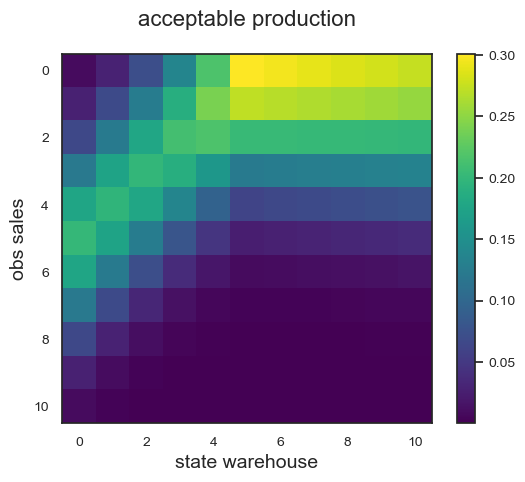

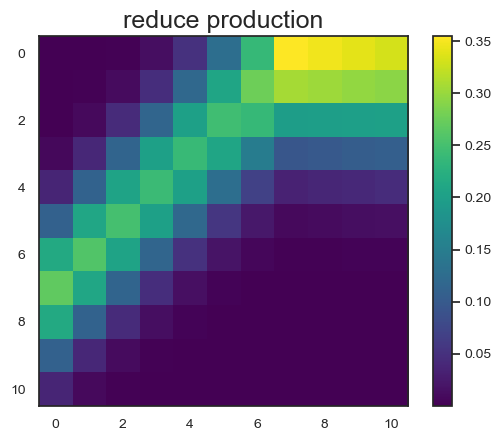

In [96]:
A1_sales = np.zeros((len(obs_sales),len(state_warehouse), len(state_context), len(state_epistemic)))

for i, state in enumerate(state_context):

    if state == 'OK production':
        soglia = 5  
        base_std = 2.0  
        std_growth = 0.05  
        
    else:
        soglia = 7  
        base_std = 1.5  
        std_growth = 0.05  

    for idx, epist in enumerate(state_epistemic):

        for j, n in enumerate(state_warehouse):

            mu = max(0, soglia-n)
            sigma = base_std + std_growth * n 

            A1_sales[:, j, i, idx] = norm.pdf(obs_sales, loc=mu, scale=sigma)

            A1_sales[:, j, i, idx] /= A1_sales[:, j, i, idx].sum()


A1[0] = A1_sales

matrix = A1_sales[:,:,0,0]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.ylabel("obs sales", fontsize=14)
plt.xlabel("state warehouse", fontsize=14)
plt.title("acceptable production", fontsize=16, pad=20)
plt.show()

matrix = A1_sales[:,:,1,0]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title("reduce production")
plt.show()

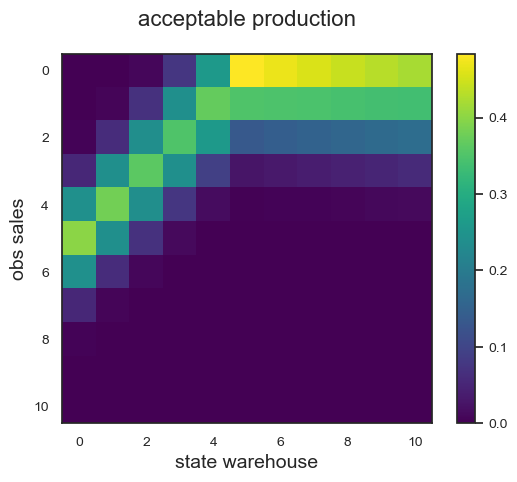

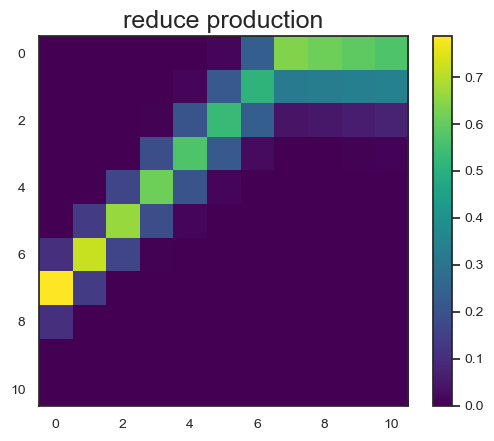

In [97]:
A2_sales = np.zeros((len(obs_sales),len(state_warehouse), len(state_context), len(state_epistemic)))

for i, state in enumerate(state_context):

    if state == 'OK production':
        soglia = 5  
        base_std = 1.0  
        std_growth = 0.05  
    else:
        soglia = 7  
        base_std = 0.5  
        std_growth = 0.05  

    for idx, epist in enumerate(state_epistemic):

        for j, n in enumerate(state_warehouse):

            mu = max(0, soglia-n)
            sigma = base_std + std_growth * n  

            A2_sales[:, j, i, idx] = norm.pdf(obs_sales, loc=mu, scale=sigma)

            A2_sales[:, j, i, idx] /= A2_sales[:, j, i, idx].sum()


A2[0] = A2_sales

matrix = A2_sales[:,:,0,0]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.ylabel("obs sales", fontsize=14)
plt.xlabel("state warehouse", fontsize=14)
plt.title("acceptable production", fontsize=16, pad=20)
plt.show()

matrix = A2_sales[:,:,1,0]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title("reduce production")
plt.show()

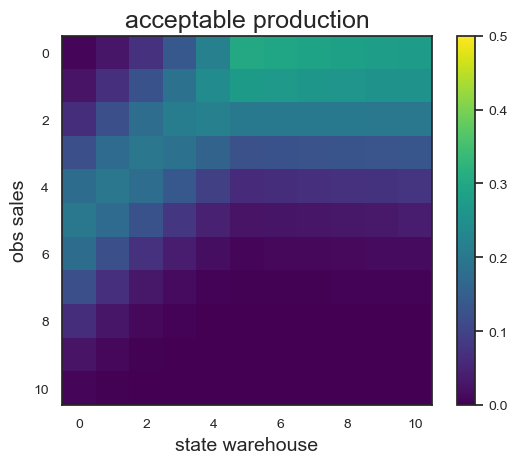

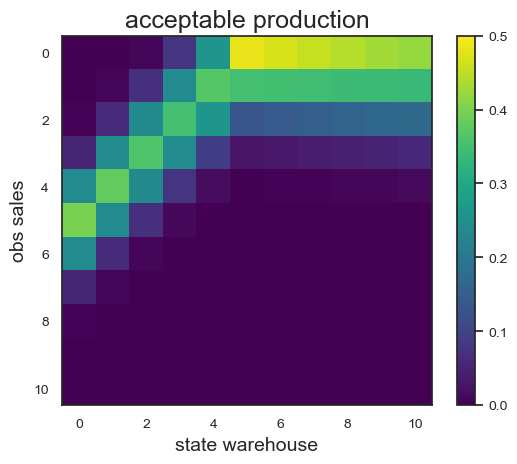

In [98]:
# Common color scale limits
vmin = 0.0
vmax = 0.5

# First plot: acceptable production
matrix = A1_sales[:, :, 0, 0]
plt.imshow(matrix, cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.ylabel("obs sales")
plt.xlabel("state warehouse")
plt.title("acceptable production")
plt.show()

# Second plot: reduce production
matrix = A2_sales[:, :, 0, 0]
plt.imshow(matrix, cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.ylabel("obs sales")
plt.xlabel("state warehouse")
plt.title("acceptable production")
plt.show()

## A[last action]

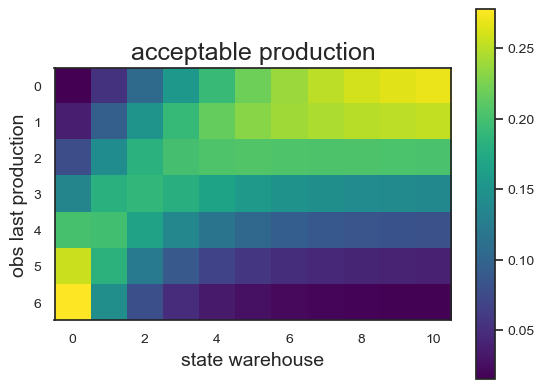

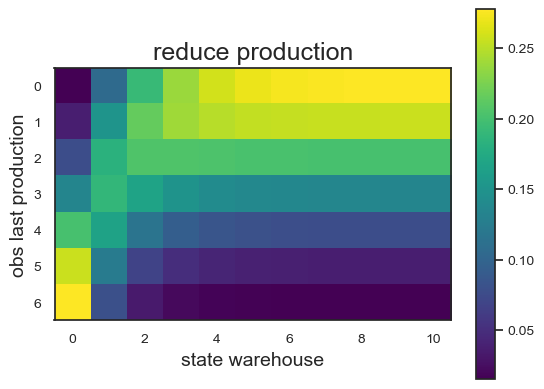

In [99]:
A1_production = np.zeros((len(obs_last_production),len(state_warehouse), len(state_context), len(state_epistemic)))

for i, state in enumerate(state_context):

    if state == 'OK production':
        max_prod = n_action - 1
        base_std = 2.5  # standard deviation
        reverse_strength = 4.0  # rate at which the mean decreases
    else:
        max_prod = n_action - 1
        base_std = 2.5  # standard deviation
        reverse_strength = 8.0  # rate at which the mean decreases

    for idx, epist in enumerate(state_epistemic):
        
        for j, n in enumerate(state_warehouse):
            # Production mean decays exponentially relative to warehouse levels
            mu = max_prod * np.exp(-reverse_strength * n / state_warehouse[-1])
            sigma = base_std

            # Compute the normal distribution for each observed production value
            A1_production[:, j, i, idx] = norm.pdf(obs_last_production, loc=mu, scale=sigma)
            
            # Normalize the column to obtain a valid probability distribution
            A1_production[:, j, i, idx] /= A1_production[:, j, i, idx].sum()


A1[1] = A1_production

# Plotting the production likelihood matrix for 'OK production' context
matrix = A1_production[:,:,0,1]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.ylabel("obs last production")
plt.xlabel("state warehouse")
plt.title("acceptable production")
plt.show()

# Plotting the production likelihood matrix for 'Reduce production' context
matrix = A1_production[:,:,1,1]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.ylabel("obs last production")
plt.xlabel("state warehouse")
plt.title("reduce production")
plt.show()

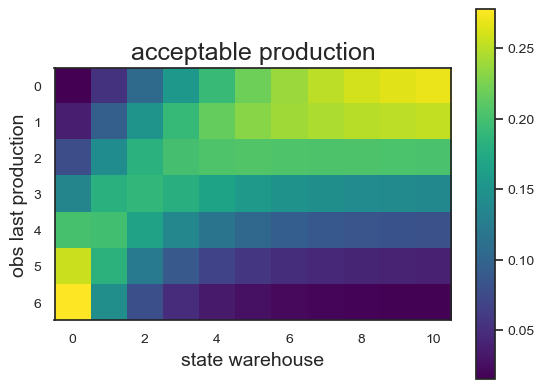

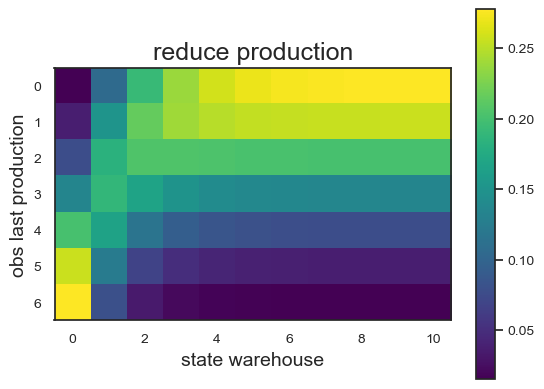

In [100]:
A2_production = np.zeros((len(obs_last_production),len(state_warehouse), len(state_context), len(state_epistemic)))

for i, state in enumerate(state_context):

    if state == 'OK production':
        max_prod = n_action - 1
        base_std = 2.5  # standard deviation
        reverse_strength = 4.0  # decay rate of the mean
    else:
        max_prod = n_action - 1
        base_std = 2.5  # standard deviation
        reverse_strength = 8.0  # decay rate of the mean

    for idx, epist in enumerate(state_epistemic):
        
        for j, n in enumerate(state_warehouse):
            # Production mean decays exponentially relative to warehouse levels
            mu = max_prod * np.exp(-reverse_strength * n / state_warehouse[-1])
            sigma = base_std

            # Calculate the normal distribution for each observed production value
            A2_production[:, j, i, idx] = norm.pdf(obs_last_production, loc=mu, scale=sigma)
            
            # Normalize the column to create a valid probability distribution
            A2_production[:, j, i, idx] /= A2_production[:, j, i, idx].sum()


A2[1] = A2_production

# Plotting the production likelihood matrix for 'OK production' context
matrix = A2_production[:,:,0,1]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.ylabel("obs last production")
plt.xlabel("state warehouse")
plt.title("acceptable production")
plt.show()

# Plotting the production likelihood matrix for 'Reduce production' context
matrix = A2_production[:,:,1,1]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.ylabel("obs last production")
plt.xlabel("state warehouse")
plt.title("reduce production")
plt.show()

## A[level_ware]

In [101]:
pf_level = 3
ic_level = 5
oc_level = 8

In [102]:
# Initialize the full A1_ware matrix
n_obs    = len(obs_level_ware)
n_ware   = len(state_warehouse)
n_ctx    = len(state_context)
n_epist  = len(state_epistemic)

A1_ware = np.zeros((n_obs, n_ware, n_ctx, n_epist))

# First, reconstruct the base matrix without context
A_base = np.zeros((n_obs, n_ware, n_epist))

for idx_e, epist in enumerate(state_epistemic):
    if epist == "Epistemic":
        # Deterministic case mapping states to categorical observations
        for j, level in enumerate(obs_level_ware):
            if level == "perfect":
                A_base[j, :pf_level, idx_e] = 1
            elif level == "in control":
                A_base[j, pf_level:ic_level, idx_e] = 1
            elif level == "loading":
                A_base[j, ic_level:oc_level, idx_e] = 1
            elif level == "out of control":
                A_base[j, oc_level:, idx_e] = 1
    else:
        # Noisy case based on the "Epistemic" slice using Gaussian smoothing
        noise_std = 0.4
        base = A_base[:, :, state_epistemic.index("Epistemic")]

        for w in range(n_ware):
            col_base = base[:, w]
            centers = np.where(col_base > 0)[0]
            if len(centers) == 0:
                # Fallback to uniform distribution if no center is found
                A_base[:, w, idx_e] = 1.0 / n_obs
            else:
                noisy_col = np.zeros(n_obs)
                for c0 in centers:
                    # Apply Gaussian noise centered on the deterministic observation
                    distances = np.abs(np.arange(n_obs) - c0)
                    gaussian = np.exp(-(distances**2) / (2 * noise_std**2))
                    noisy_col += gaussian
                noisy_col = np.clip(noisy_col, 0, None)
                noisy_col /= noisy_col.sum()
                A_base[:, w, idx_e] = noisy_col

# Define likelihood weights P(context | observation)
# Rows = Observations, Columns = Contexts
context_weights = np.array([
    [0.99, 0.01],  # perfect
    [0.80, 0.20],  # in control
    [0.20, 0.80],  # loading
    [0.01, 0.99],  # out of control
])  # shape = (n_obs, n_ctx)

# Expand A_base across the context dimension and re-normalize
for e in range(n_epist):
    for w in range(n_ware):
        base_col = A_base[:, w, e]
        for c in range(n_ctx):
            # Apply context weights to the base likelihood
            raw = base_col * context_weights[:, c]
            if raw.sum() == 0:
                # Fallback if the resulting column sums to zero
                raw = base_col.copy()
            A1_ware[:, w, c, e] = raw / raw.sum()

# Assign matrices to pymdp agents
A1[2] = A1_ware
A2[2] = A1_ware

# Verification
assert utils.is_normalized(A1_ware), "A1_ware is NOT normalized!"

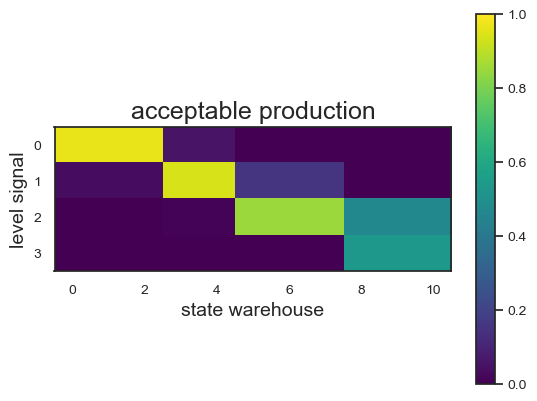

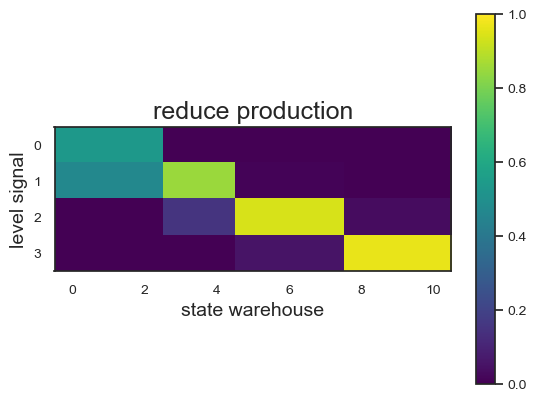

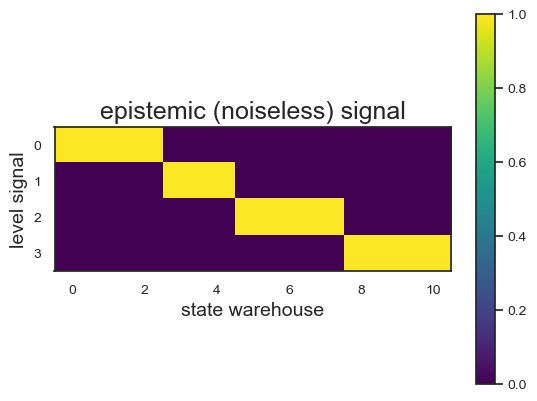

In [103]:
matrix = A1_ware[:,:,0,1]
plt.imshow(matrix, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.ylabel("level signal")
plt.xlabel("state warehouse")
plt.title("acceptable production")
plt.show()

matrix = A1_ware[:,:,1,1]
plt.imshow(matrix, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.ylabel("level signal")
plt.xlabel("state warehouse")
plt.title("reduce production")
plt.show()

matrix = A1_ware[:,:,0,0]
plt.imshow(matrix, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.ylabel("level signal")
plt.xlabel("state warehouse")
plt.title("epistemic (noiseless) signal")
plt.show()

## A[analysis]

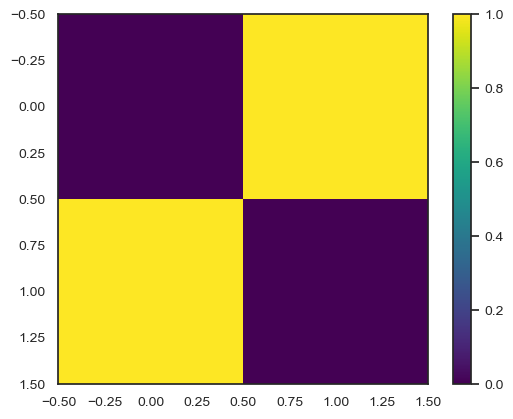

In [104]:
A1_analysis = np.zeros((len(obs_analysis),len(state_warehouse),len(state_context),len(state_epistemic)))
A2_analysis = np.zeros((len(obs_analysis),len(state_warehouse),len(state_context),len(state_epistemic)))

for j, state in enumerate(state_context):
    for i, ware in enumerate(state_warehouse):
        A1_analysis[1,i,j,0] = 1
        A1_analysis[0,i,j,1] = 1

A1[3] = A1_analysis
A2[3] = A1_analysis

matrix = A1_analysis[:,6,1,:]
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.show()

# Transition probabilities matrices

In [105]:
B1 = utils.obj_array(n_factors)
B2 = utils.obj_array(n_factors)

## B[warehouse]

In [106]:
B_warehouse1 = np.zeros((len(state_warehouse), len(state_warehouse), len(action_production)))

preferred_sales = BR_1_idx  # target state is s-2
# Noise parameter
std_dev = 1.0  # standard deviation of the noise

for s in range(len(state_warehouse)):  # Initial state
    for a in range(len(action_production)):  # Production action

        # Distribution center = state + production - 2
        mu = s + a - preferred_sales
        mu = np.clip(mu, 0, size_warehouse - 1)

        for s_prime in range(len(state_warehouse)):
            prob = norm.pdf(s_prime, loc=mu, scale=std_dev)
            B_warehouse1[s_prime, s, a] = prob

        # Normalize the column to make it a probability distribution
        B_warehouse1[:, s, a] /= B_warehouse1[:, s, a].sum()

In [107]:
B_warehouse2 = np.zeros((len(state_warehouse), len(state_warehouse), len(action_production)))

preferred_sales = BR_2_idx  # target state is s-2
# Noise parameter
std_dev = 1.0  # standard deviation of the noise

for s in range(len(state_warehouse)):  # Initial state
    for a in range(len(action_production)):  # Production action

        # Distribution center = state + production - 2
        mu = s + a - preferred_sales
        mu = np.clip(mu, 0, size_warehouse - 1)

        for s_prime in range(len(state_warehouse)):
            prob = norm.pdf(s_prime, loc=mu, scale=std_dev)
            B_warehouse2[s_prime, s, a] = prob

        # Normalize the column to make it a probability distribution
        B_warehouse2[:, s, a] /= B_warehouse2[:, s, a].sum()

In [108]:
B1[0] = B_warehouse1
B2[0] = B_warehouse2

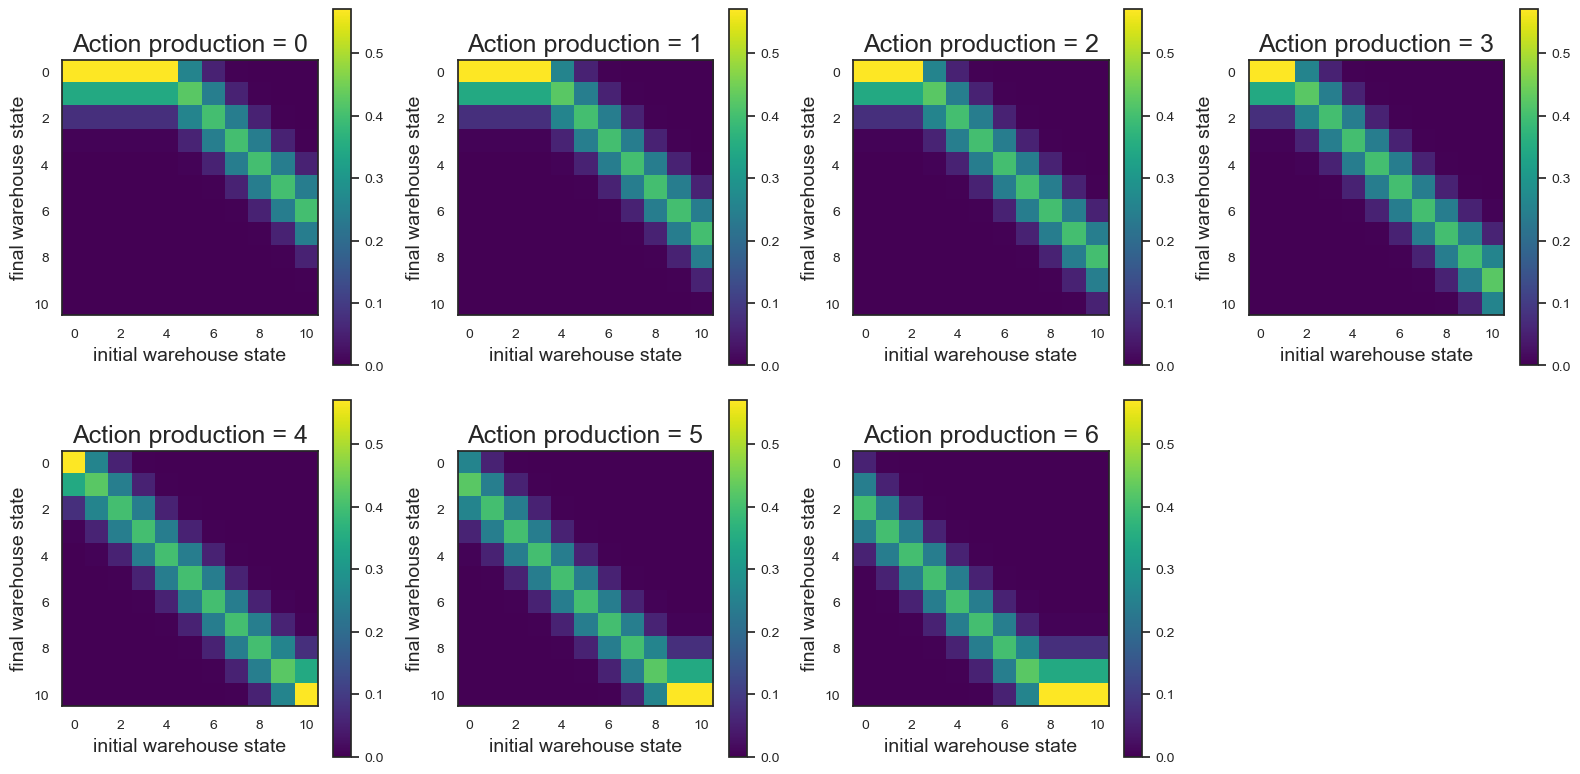

In [109]:
# Determine the number of rows and columns for the subplots
matrix = B_warehouse2
n_actions = matrix.shape[2]
n_cols = 4 #int(np.ceil(np.sqrt(n_actions)))
n_rows = 2 #int(np.ceil(n_actions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

# Flatten the axes for easy iteration (works even if the grid is not square)
axes = axes.flatten()

for i in range(n_actions):
    im = axes[i].imshow(matrix[:, :, i], cmap='viridis', interpolation='nearest')
    axes[i].set_title(f'Action production = {i}')
    axes[i].set_xlabel('initial warehouse state')
    axes[i].set_ylabel('final warehouse state')
    fig.colorbar(im, ax=axes[i])

# Hide any empty subplots
for j in range(n_actions, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## B[context]

In [110]:
B_context = np.zeros((len(state_context), len(state_context), len(action_context)))

p_correct = 0.5 # probability of staying in the previous context

for a in range(len(action_context)):
    for s in range(len(state_context)):
        for s_prime in range(len(state_context)):
            if s_prime == s:
                B_context[s_prime, s, a] = p_correct
            else:                    
                B_context[s_prime, s, a] = (1 - p_correct) / (len(state_context) - 1)

    B_context[:, :, a] /= B_context[:, :, a].sum(axis=0)

B1[1] = B_context
B2[1] = B_context

## B[state]

In [111]:
B_epistemic = np.zeros((len(state_epistemic), len(state_epistemic), len(action_analysis)))

for i, a in enumerate(action_analysis):
    if a == 'Ware analysis':
        B_epistemic[0,:,i] = 1
    else:
        B_epistemic[1,:,i] = 1 

B1[2] = B_epistemic
B2[2] = B_epistemic

# Goal prior

In [112]:
C1 = utils.obj_array_zeros(num_obs)
C2 = utils.obj_array_zeros(num_obs)

## C[sales]

In [113]:
C_sales_1 = revenue(market_price=assumed_market_price_1, sales=obs_sales)
C_sales_2 = revenue(market_price=assumed_market_price_2, sales=obs_sales)

C1[0] = C_sales_1
C2[0] = C_sales_2

## C[production]

In [114]:
C_production_1 = -cost_prod_1 * action_production
C_production_2 = -cost_prod_2 * action_production

C1[1] = C_production_1
C2[1] = C_production_2

## C[ware]
Se supero una certa soglia magari devo sostenere dei costi di gestione maggiori, se la situazione è critica dei costi di smaltimento.

In [115]:
C_ware = np.array([0, -15, -75, -100])

C1[2] = C_ware
C2[2] = C_ware

## C[analysis]

In [116]:
C_analysis = np.array([0, -3.5])

C1[3] = C_analysis
C2[3] = C_analysis

# State Prior

In [117]:
D1 = utils.obj_array(n_factors)
D2 = utils.obj_array(n_factors)

D_warehouse = utils.onehot(0, len(state_warehouse))
D_context = utils.onehot(0, len(state_context))
D_epistemic = utils.onehot(1, len(state_epistemic))

D1[0] = D_warehouse
D2[0] = D_warehouse

D1[1] = D_context
D2[1] = D_context

D1[2] = D_epistemic
D2[2] = D_epistemic


# Agent initialization

In [118]:
B1_prior = utils.dirichlet_like(B1)
B2_prior = utils.dirichlet_like(B2)

In [119]:
my_agent1 = Agent(A = A1, B = B1, C = C1, D = D1, policy_len=3,
                  use_states_info_gain = False,
                  use_param_info_gain = True,
                  scale_state=0.1)

In [120]:
my_agent2 = Agent(A = A2, B = B2, C = C2, D = D2, policy_len=3,
                  use_states_info_gain = False,
                  use_param_info_gain = True,
                  scale_state=0.1)

# Environment

In [121]:
class CournotMarket(object):

    def __init__(self, reputation=0.5, total_demand=5, max_customer_price=10, sensibility=1, warehouse_1=0, warehouse_2=0):
        self.reputation = float(reputation)
        self.total_demand = float(total_demand)
        self.max_customer_price = float(max_customer_price)
        self.sensibility = float(sensibility)
        self.warehouse_1 = int(warehouse_1)
        self.warehouse_2 = int(warehouse_2)
    

    def step(self, action1, action2, time_step):
        if time_step == 6:
            self.total_demand = 6
        if time_step == 11: 
            self.total_demand = 4
        if time_step == 15:
            self.total_demand = 14
            self.max_customer_price = 45

        real_total_demand = self.total_demand #+ np.random.random_integers(-1, 1)
        print(f"Real total demand: {real_total_demand}")
        
        total_product_1 = action1[0] + self.warehouse_1
        total_product_2 = action2[0] + self.warehouse_2
        product_availability = total_product_1 + total_product_2
        
        market_price = max(0, self.max_customer_price - self.sensibility * product_availability)
        
        preferred_demand_1 = int(real_total_demand * self.reputation)
        preferred_demand_2 = real_total_demand - preferred_demand_1
        
        actual_sales_1 = min(total_product_1, preferred_demand_1)
        actual_sales_2 = min(total_product_2, preferred_demand_2)
        
        # people excluded from purchasing from their preferred firm        
        remaining_demand_1 = preferred_demand_1 - actual_sales_1
        remaining_demand_2 = preferred_demand_2 - actual_sales_2
        
        if remaining_demand_1 > 0 and total_product_2 > actual_sales_2:
            extra_sales_2 = min(total_product_2 - actual_sales_2, remaining_demand_1)
            actual_sales_2 += extra_sales_2
            remaining_demand_1 -= extra_sales_2
        
        if remaining_demand_2 > 0 and total_product_1 > actual_sales_1:
            extra_sales_1 = min(total_product_1 - actual_sales_1, remaining_demand_2)
            actual_sales_1 += extra_sales_1
            remaining_demand_2 -= extra_sales_1
        
        self.warehouse_1 = total_product_1 - actual_sales_1
        self.warehouse_2 = total_product_2 - actual_sales_2

        if action1[2] == 1:
            analysis_1 = "Analysis"
        else:
            analysis_1 = "Null"
        
        if action2[2] == 1:
            analysis_2 = "Analysis"
        else:
            analysis_2 = "Null"

        obs_sales = [int(actual_sales_1), int(actual_sales_2)] 
        obs_last_prod = [int(action1[0]), int(action2[0])] 
        h_obs_warehouse = [int(self.warehouse_1), int(self.warehouse_2)]
        obs_level_ware = return_level(h_obs_warehouse,pf_level, ic_level, oc_level)
        obs_analysis = [analysis_1, analysis_2]
        return obs_sales, market_price, obs_last_prod, obs_level_ware, obs_analysis, h_obs_warehouse

# Active Inference Loop

In [122]:
prod1 = []
prod2 = []
warehouse1 = [0]
warehouse2 = [0]
sold1 = []
sold2 = []

infer_ware1 = []
infer_ware2 = []

infer_context1 = []
infer_context2 = []

epistemic_choice1 = []
epistemic_choice2 = []

real_price =[]
predicted_price1 = []
predicted_price2 = []

BR_1_plot = []
BR_2_plot = []

Max_price = []

In [123]:
def run_active_inference_loop(my_agent1, my_agent2, my_env, size_warehouse, T=5):
    """Runs an active inference loop where alpha increases over time."""

    market_price = assumed_market_price_1
    size_ware = size_warehouse
    size_warehouse = np.arange(size_warehouse)
    obs1 = [0, 0, obs_level_ware.index("perfect"), obs_analysis.index("Null")] 
    obs2 = [0, 0, obs_level_ware.index("perfect"), obs_analysis.index("Null")]

    starting_sales_states = [0, 0]
    obs_last_sales = starting_sales_states

    starting_sales_states = [0, 0]
    obs_last_sales = starting_sales_states

    null_instance = {f"prod_{i}": v for i, v in enumerate(obs_last_sales)}

    SRP_1.learn_one(null_instance, market_price)
    SRP_2.learn_one(null_instance, market_price)

    old_max_price_1 = SRP_1.predict_one(null_instance) 
    old_max_price_2 = SRP_2.predict_one(null_instance) 

    BR_1 = (assumed_market_price_1 - 2 * cost_prod_1 + cost_prod_2) / (3*sensibility)
    BR_2 = (assumed_market_price_2 - 2 * cost_prod_2 + cost_prod_1) / (3*sensibility)


    for t in range(T):
        qs_ware1, qs_ctx1, qs_epist1 = my_agent1.infer_states(obs1)
        qs_ware2, qs_ctx2, qs_epist2 = my_agent2.infer_states(obs2)
        print("supposed warehouse 1:", get_max_prob_index(qs_ware1))
        print("context 1:", get_max_prob_index(qs_ctx1))
        print("analisi 1:", get_max_prob_index(qs_epist1))
        print("supposed warehouse 2:", get_max_prob_index(qs_ware2))
        print("context 2:", get_max_prob_index(qs_ctx2))
        print("analisi 2:", get_max_prob_index(qs_epist2))
        
        # Update preference distribution (C matrix) using a custom revenue function
        my_agent1.C[0] = revenue_SRP(SRP_1, my_sales=size_warehouse, sales_competitor=obs_last_sales[1])
        my_agent2.C[0] = revenue_SRP(SRP_2, my_sales=size_warehouse, sales_competitor=obs_last_sales[0])

        # Infer policies
        q_pi_1, efe_1 = my_agent1.infer_policies()
        q_pi_2, efe_2 = my_agent2.infer_policies()

        # Sample actions based on stochastic policy selection
        action_1 = my_agent1.sample_action()
        action_2 = my_agent2.sample_action()
        
        # Environment step
        obs_sales, market_price, obs_last_prod, obs_level, obs_analysis_signal, h_obs_warehouse = my_env.step(action_1, action_2, t)

        step_print(produzione1=obs_last_prod[0], produzione2=obs_last_prod[1], 
                   segnale1=obs_analysis_signal[0], segnale2=obs_analysis_signal[1],
                   vendite1=obs_sales[0], vendite2=obs_sales[1], 
                   magazzino1=h_obs_warehouse[0], magazzino2=h_obs_warehouse[1],
                   ware_levels=obs_level)

        instance = {f"prod_{i}": v for i, v in enumerate(obs_sales)}

        price_hat_1 = SRP_1.predict_one(instance)
        price_hat_2 = SRP_2.predict_one(instance)
        SRP_1.learn_one(instance, market_price)
        SRP_2.learn_one(instance, market_price)

        #---------- Update B (if needed) ----------------#
        Max_price.append(SRP_1.predict_one(null_instance)+5)
        
        new_max_price_1 = SRP_1.predict_one(null_instance) + 5
        new_max_price_2 = SRP_2.predict_one(null_instance) + 5

        
        print("old max price 1:", old_max_price_1)
        print("new max price 1:", new_max_price_1)
        print("old max price 2:", old_max_price_2)
        print("new max price 2:", new_max_price_2)

        if (abs(new_max_price_1 - old_max_price_1))/old_max_price_1 > 0.1:
            BR_1 = (new_max_price_1 - 2 * cost_prod_1 + cost_prod_2) / (3*sensibility)
            BR_1_idx = round(min(BR_1, max_production))
            print(f"NEW BR 1: {BR_1_idx}")
            B1_new = build_transition_matrix(preferred_sales=BR_1_idx, state_warehouse=state_warehouse, 
                                             action_production=action_production, size_warehouse=size_ware)
            my_agent1.B[0] = B1_new
        
        if (abs(new_max_price_1 - old_max_price_1))/old_max_price_1 > 0.1:
            BR_2 = (new_max_price_2 - 2 * cost_prod_2 + cost_prod_1) / (3*sensibility)
            BR_2_idx = round(min(BR_2, max_production))
            print(f"NEW BR 2: {BR_2_idx}")
            B1_new = build_transition_matrix(preferred_sales=BR_2_idx, state_warehouse=state_warehouse, 
                                             action_production=action_production, size_warehouse=size_ware)
            my_agent2.B[0] = B1_new

        old_max_price_1 = new_max_price_1
        old_max_price_2 = new_max_price_2

        BR_1_plot.append(BR_1)
        BR_2_plot.append(BR_2)

        #----------- end update section -----------------#

        # Update observations
        obs1 = [obs_sales[0], obs_last_prod[0], obs_level_ware.index(obs_level[0]), 
                obs_analysis.index(obs_analysis_signal[0])]
        obs2 = [obs_sales[1], obs_last_prod[1], obs_level_ware.index(obs_level[1]), 
                obs_analysis.index(obs_analysis_signal[1])]

        obs_last_sales = obs_sales

        # Plot variables

        # 1) plot about production and sales
        prod1.append(obs_last_prod[0])
        prod2.append(obs_last_prod[1])
        warehouse1.append(h_obs_warehouse[0])
        warehouse2.append(h_obs_warehouse[1])
        sold1.append(obs_sales[0])
        sold2.append(obs_sales[1])
        infer_ware1.append(get_max_prob_index(qs_ware1))
        infer_ware2.append(get_max_prob_index(qs_ware2))

        epistemic_choice1.append(get_max_prob_index(qs_epist1))
        epistemic_choice2.append(get_max_prob_index(qs_epist2))

        infer_context1.append(get_max_prob_index(qs_ctx1))
        infer_context2.append(get_max_prob_index(qs_ctx2))

        # 2) plot about price estimation
        real_price.append(market_price)
        predicted_price1.append(price_hat_1)
        predicted_price2.append(price_hat_2)

# Main


In [124]:
reputation_env = 0.5
total_demand_env = 10
env = CournotMarket(reputation = reputation_env, total_demand = total_demand_env, 
                    max_customer_price = max_customer_price, sensibility = sensibility)

T = 25

run_active_inference_loop(my_agent1, my_agent2, env, size_warehouse=size_warehouse, T = T)

supposed warehouse 1: 0
context 1: 0
analisi 1: 1
supposed warehouse 2: 0
context 2: 0
analisi 2: 1
Real total demand: 10.0
Produzione 1: 6, Produzione 2: 5
Segnale analisi 1: Analysis, Segnale analisi 2: Analysis
Vendite 1: 5, Vendite 2: 5
Magazzino 1: (1, 'perfect'), Magazzino 2: (0, 'perfect')
--------------------------------------------------
old max price 1: 30.0
new max price 1: 29.72809266756635
old max price 2: 30.0
new max price 2: 29.72809266756635
supposed warehouse 1: 0
context 1: 0
analisi 1: 0
supposed warehouse 2: 1
context 2: 0
analisi 2: 0
Real total demand: 10.0
Produzione 1: 5, Produzione 2: 5
Segnale analisi 1: Analysis, Segnale analisi 2: Null
Vendite 1: 5, Vendite 2: 5
Magazzino 1: (1, 'perfect'), Magazzino 2: (0, 'perfect')
--------------------------------------------------
old max price 1: 29.72809266756635
new max price 1: 27.668874883286648
old max price 2: 29.72809266756635
new max price 2: 27.668874883286648
supposed warehouse 1: 0
context 1: 0
analisi 1: 0


# Plot

In [125]:
time = np.arange(T)

In [126]:
BR_1_real = np.array([(30 - 2 * cost_prod_1 + cost_prod_2) / (3*sensibility) if t<15 else (45 - 2 * cost_prod_1 + cost_prod_2) / (3*sensibility) for t in time])
BR_2_real = np.array([(30 - 2 * cost_prod_2 + cost_prod_1) / (3*sensibility) if t<15 else (45 - 2 * cost_prod_2 + cost_prod_1) / (3*sensibility) for t in time])

In [127]:
infer_ware_plot1 = [x + y for x, y in zip(infer_ware1, prod1)]
infer_ware_plot2 = [x + y for x, y in zip(infer_ware2, prod2)]

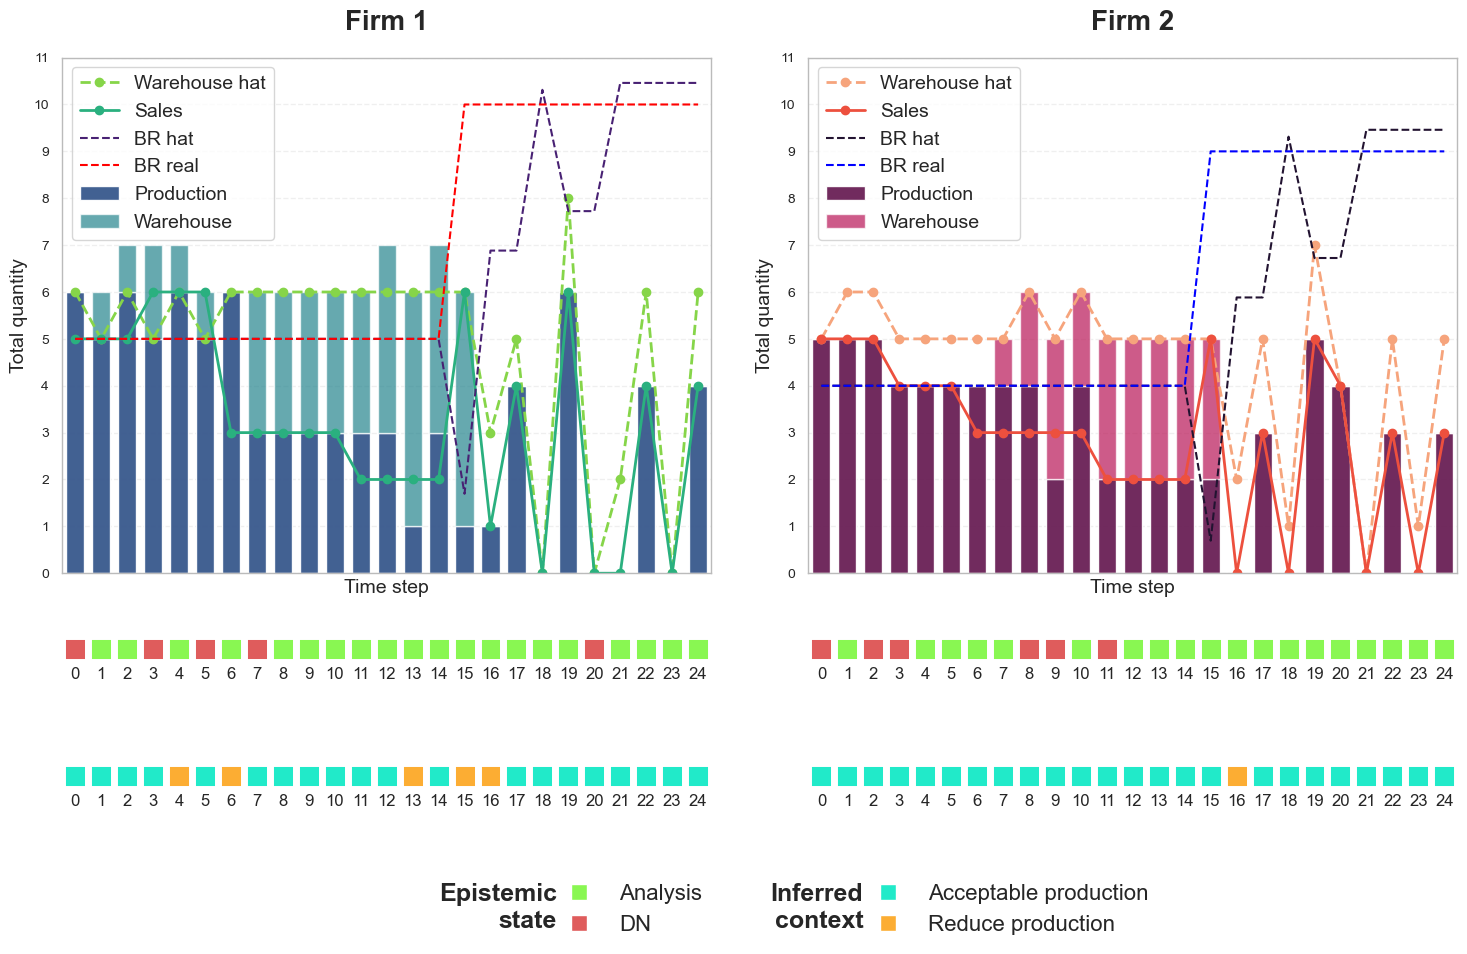

In [129]:
# =========================
# General Aesthetic Setup
# =========================
sns.set(style="white")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

bar_width = 0.7

# =========================
# Color Palettes
# =========================
palette1 = sns.color_palette("viridis", 10)
palette2 = sns.color_palette("rocket", 10)

colors_agent1 = {
    'produzione': palette1[2],
    'magazzino': palette1[4],
    'vendite': palette1[6],
    'inferenza': palette1[8],
    'BR': palette1[0]
}

colors_agent2 = {
    'produzione': palette2[2],
    'magazzino': palette2[4],
    'vendite': palette2[6],
    'inferenza': palette2[8],
    'BR': palette2[0]
}

color_dn = '#df5c5c'
color_analisi = '#89f752'
color_ok = '#21eac9'
color_reduce = '#fcad33'

# =========================
# Figure Layout
# =========================
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    height_ratios=[5, 1, 1],
    hspace=0.1,
    wspace=0.15
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax5 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax6 = fig.add_subplot(gs[2, 1], sharex=ax2)

# =========================
# Main Plots (Firm 1 & 2)
# =========================
for ax, prod, ware, infer, sold, br_hat, br_real, colors in zip(
        [ax1, ax2],
        [prod1, prod2],
        [warehouse1, warehouse2],
        [infer_ware_plot1, infer_ware_plot2],
        [sold1, sold2],
        [BR_1_plot, BR_2_plot],
        [BR_1_real, BR_2_real],
        [colors_agent1, colors_agent2]):

    ax.bar(time, prod, width=bar_width, color=colors['produzione'], alpha=0.95, label='Production')
    ax.bar(time, ware[0:len(time)], width=bar_width, bottom=prod, color=colors['magazzino'], alpha=0.7, label='Warehouse')
    ax.plot(time, infer, color=colors['inferenza'], marker='o', linestyle='--', linewidth=2, label='Warehouse hat')
    ax.plot(time, sold, color=colors['vendite'], marker='o', linestyle='-', linewidth=2, label='Sales')
    ax.plot(time, br_hat, color=colors['BR'], linestyle='--', linewidth=1.5, label='BR hat')
    ax.plot(time, br_real, color='red' if ax == ax1 else 'blue', linestyle='--', linewidth=1.5, label='BR real')
    
    ax.set_ylim(0, 11)
    ax.set_yticks(range(12))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Total quantity')
    ax.set_title('Firm 1' if ax==ax1 else 'Firm 2', pad=20, fontsize=20, fontweight='bold')
    ax.legend(frameon=True, fontsize=14, loc='upper left', ncol=1)
    
    for spine in ax.spines.values():
        spine.set_color('#bbbbbb')
        spine.set_linewidth(1)

# =========================
# Epistemic and Context Grids
# =========================
for ax, states, colors_pair in zip([ax3, ax4, ax5, ax6],
                                   [epistemic_choice1, epistemic_choice2, infer_context1, infer_context2],
                                   [(color_analisi, color_dn), (color_analisi, color_dn), (color_ok, color_reduce), (color_ok, color_reduce)]):
    ax.set_ylim(0,1)
    ax.set_yticks([])
    ax.set_aspect('equal')
    
    for t, val in zip(time, states):
        c = colors_pair[int(val)]
        ax.bar(t, 1, width=1, color=c, edgecolor='white', linewidth=5)
    
    ax.set_xlim(time[0]-0.5, time[-1]+0.5)
    ax.tick_params(axis='x', length=0)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

# =========================
# Time Step Labels
# =========================
for ax in [ax3, ax4, ax5, ax6]:
    ax.set_xticks(time)
    ax.set_xticklabels(time, fontsize=12)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', labelbottom=False)

# =========================
# Vertical Legends for Epistemic and Context
# =========================
legend_epistemic = [
    Line2D([0],[0], marker='s', color='w', label='Analysis',
           markerfacecolor=color_analisi, markersize=12),
    Line2D([0],[0], marker='s', color='w', label='DN',
           markerfacecolor=color_dn, markersize=12)
]

legend_context = [
    Line2D([0],[0], marker='s', color='w', label='Acceptable production',
           markerfacecolor=color_ok, markersize=12),
    Line2D([0],[0], marker='s', color='w', label='Reduce production',
           markerfacecolor=color_reduce, markersize=12)
]

fig.legend(handles=legend_epistemic,
           loc='lower center',
           bbox_to_anchor=(0.44, -0.0175),
           frameon=False,
           ncol=1,
           fontsize=16)

fig.legend(handles=legend_context,
           loc='lower center',
           bbox_to_anchor=(0.65, -0.0175),
           frameon=False,
           ncol=1,
           fontsize=16)

fig.text(0.40, 0.03, 'Epistemic\nstate', ha='right', va='center', fontsize=18, fontweight='bold')
fig.text(0.57, 0.03, 'Inferred\ncontext', ha='right', va='center', fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()